# Linear Probe + T-SNE: MIMIC-IV Checkpoint on PTB-XL

Evaluates the MIMIC-IV pretrained checkpoint (`checkpoints/mimic/`) on PTB-XL. The MIMIC run used:
- `dev` preset (D=384, 6 blocks)
- 12 leads
- 100 Hz, 1000 samples per record (10 s)

PTB-XL records here are 500 Hz × 2500 samples × 12 leads. We downsample to 1000 samples (matching the MIMIC geometry) and keep all 12 leads. If any of `III, aVR, aVL, aVF` are missing they can be recovered with Einthoven / Goldberger relations — PTB-XL ships all 12 already, so this is a defensive check.

In [1]:
from __future__ import annotations

import copy
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path.cwd()
if not (ROOT / "src" / "encoder.py").is_file():
    ROOT = ROOT.parent
if not (ROOT / "src" / "encoder.py").is_file():
    ROOT = Path("/home/aimakeradmin/shady/TS-JEPA")
sys.path.insert(0, str(ROOT))

from src.configs.presets import dev_preset
from src.encoder import ECGEncoder
from src.tokenizer import ECGTokenizer
from src.data.ptbxl_dataset import PTBXLDataset
from collapse_investigation.analysis_utils import strip_known_prefixes, unwrap_checkpoint

CHECKPOINT = ROOT / "checkpoints" / "mimic" / "checkpoint_best.pt"
PTBXL_DATA_DIR = ROOT / "data" / "ptbxl_500hz_2500_raw"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
print("ROOT:", ROOT)
print("device:", device)
print("CHECKPOINT:", CHECKPOINT)
print("PTBXL_DATA_DIR:", PTBXL_DATA_DIR)

ROOT: /home/aimakeradmin/shady/TS-JEPA
device: cuda
CHECKPOINT: /home/aimakeradmin/shady/TS-JEPA/checkpoints/mimic/checkpoint_best.pt
PTBXL_DATA_DIR: /home/aimakeradmin/shady/TS-JEPA/data/ptbxl_500hz_2500_raw


## Build encoder matching MIMIC geometry and load weights

MIMIC pretraining used `dev` preset with 12 leads and signal length 1000 (100 Hz). Override `num_leads=12` and `num_patches=20` so the 2D sincos positional embedding has the right (C, N) grid.

In [2]:
tok_cfg, enc_cfg, _ = dev_preset()
# MIMIC checkpoint uses the FFN tokenizer (Linear 50->256, GELU, Linear 256->384).
tok_cfg.kind = "ffn"
tok_cfg.ffn_hidden_dim = 256
enc_cfg.num_leads = 12
enc_cfg.num_patches = 20  # 1000 samples / 50 patch_size
enc_cfg.use_flash = True

tokenizer = ECGTokenizer(tok_cfg)
encoder = ECGEncoder(enc_cfg, tokenizer)


def load_mimic_encoder(module: ECGEncoder, path: Path) -> None:
    blob = torch.load(path, map_location="cpu", weights_only=False)
    state = strip_known_prefixes(unwrap_checkpoint(blob))
    # The MIMIC checkpoint names the tokenizer Sequential `ffn`; current code names it `proj`.
    remapped = {}
    for k, v in state.items():
        nk = k.replace("tokenizer.ffn.", "tokenizer.proj.") if k.startswith("tokenizer.ffn.") else k
        remapped[nk] = v
    module.load_state_dict(remapped, strict=True)


load_mimic_encoder(encoder, CHECKPOINT)
encoder = encoder.to(device).eval()
for p in encoder.parameters():
    p.requires_grad_(False)
tokenizer = encoder.tokenizer

print("encoder config:", enc_cfg)
print("tokenizer kind:", tok_cfg.kind, "hidden:", tok_cfg.ffn_hidden_dim)
print("expected wave shape:", (enc_cfg.num_leads, enc_cfg.num_patches * enc_cfg.patch_size))

encoder config: EncoderConfig(num_leads=12, patch_size=50, num_patches=20, embed_dim=384, depth=6, num_heads=8, mlp_ratio=4.0, dropout=0.0, drop_path=0.1, use_flash=True, qkv_bias=True)
tokenizer kind: ffn hidden: 256
expected wave shape: (12, 1000)


## Prepare PTB-XL signals

- Downsample 2500 → 1000 samples via linear interpolation (approximates 100 Hz over the original 5 s window).
- Ensure all 12 leads are present. If only the 8 independent leads are provided (`I, II, V1–V6`), reconstruct the limb leads via:
    - III  = II - I
    - aVR  = -(I + II) / 2
    - aVL  = (I - III) / 2 = I - II / 2
    - aVF  = (II + III) / 2 = II - I / 2
  
  Order: `[I, II, III, aVR, aVL, aVF, V1, V2, V3, V4, V5, V6]`.

In [3]:
TARGET_T = enc_cfg.num_patches * enc_cfg.patch_size  # 1000
NUM_LEADS = enc_cfg.num_leads  # 12


def ensure_12_leads(x: torch.Tensor) -> torch.Tensor:
    """If x has 8 leads (I, II, V1..V6) reconstruct the 4 limb leads.
    Returns tensor of shape (B, 12, T) in canonical order.
    """
    if x.shape[1] == 12:
        return x
    if x.shape[1] != 8:
        raise ValueError(f"Expected 8 or 12 leads, got {x.shape[1]}")
    I = x[:, 0:1]
    II = x[:, 1:2]
    chest = x[:, 2:8]  # V1..V6
    III = II - I
    aVR = -(I + II) / 2
    aVL = (I - III) / 2
    aVF = (II + III) / 2
    return torch.cat([I, II, III, aVR, aVL, aVF, chest], dim=1)


def prepare_signal(x: torch.Tensor) -> torch.Tensor:
    """PTB-XL wave (B, 12, T) -> (B, 12, 1000) matching MIMIC geometry."""
    x = ensure_12_leads(x)
    if x.shape[-1] != TARGET_T:
        x = F.interpolate(x, size=TARGET_T, mode="linear", align_corners=False)
    return x


trainset = PTBXLDataset(PTBXL_DATA_DIR, split="train", return_labels=True)
valset = PTBXLDataset(PTBXL_DATA_DIR, split="val", return_labels=True)
testset = PTBXLDataset(PTBXL_DATA_DIR, split="test", return_labels=True)
print("train/val/test:", len(trainset), len(valset), len(testset))

xb = torch.stack([trainset[i][0] for i in range(2)]).to(device)
yb = prepare_signal(xb)
patches = tokenizer.patchify(yb)
with torch.no_grad(), torch.amp.autocast("cuda", enabled=(device.type == "cuda" and enc_cfg.use_flash)):
    zb = encoder.forward_all(patches).mean(dim=1)
print("raw batch:", tuple(xb.shape))
print("prepared batch:", tuple(yb.shape))
print("patches:", tuple(patches.shape))
print("pooled features:", tuple(zb.shape))

train/val/test: 17111 2156 2163
raw batch: (2, 12, 2500)
prepared batch: (2, 12, 1000)
patches: (2, 12, 20, 50)
pooled features: (2, 384)


## Extract pooled features

In [4]:
def effective_rank(x: torch.Tensor, eps: float = 1e-12) -> float:
    x = x.float()
    x = x - x.mean(dim=0, keepdim=True)
    s = torch.linalg.svdvals(x)
    p = s / s.sum().clamp_min(eps)
    entropy = -(p * (p + eps).log()).sum()
    return float(entropy.exp().cpu())


def extract_features(dataset, batch_size: int = 256):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    features, labels = [], []
    encoder.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda" and enc_cfg.use_flash)):
                waves = prepare_signal(x)
                patches = tokenizer.patchify(waves)
                z = encoder.forward_all(patches).mean(dim=1)
            features.append(z.float().cpu())
            labels.append(y.float().cpu())
    return torch.cat(features), torch.cat(labels)

train_features, train_labels = extract_features(trainset)
val_features, val_labels = extract_features(valset)
test_features, test_labels = extract_features(testset)
print("train features:", train_features.shape, "eRank", effective_rank(train_features))
print("val features:  ", val_features.shape, "eRank", effective_rank(val_features))
print("test features: ", test_features.shape, "eRank", effective_rank(test_features))

train features: torch.Size([17111, 384]) eRank 142.328125
val features:   torch.Size([2156, 384]) eRank 125.90479278564453
test features:  torch.Size([2163, 384]) eRank 148.27720642089844


## Linear probe

In [5]:
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score

NUM_CLASSES = train_labels.shape[1]
probe_train = TensorDataset(train_features, train_labels)
probe_val = TensorDataset(val_features, val_labels)
probe_test = TensorDataset(test_features, test_labels)
probe_train_loader = DataLoader(probe_train, batch_size=512, shuffle=True)
probe_val_loader = DataLoader(probe_val, batch_size=512, shuffle=False)
probe_test_loader = DataLoader(probe_test, batch_size=512, shuffle=False)

pos_counts = train_labels.sum(dim=0)
neg_counts = train_labels.shape[0] - pos_counts
pos_weight = (neg_counts / pos_counts.clamp_min(1.0)).to(device)
print("pos_weight:", pos_weight)

linear_head = nn.Linear(train_features.shape[1], NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(linear_head.parameters(), lr=3e-3)


def run_epoch() -> float:
    linear_head.train()
    total = 0.0
    for x, y in probe_train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(linear_head(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / max(len(probe_train_loader), 1)


def evaluate_probe(loader):
    linear_head.eval()
    probs, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = linear_head(x.to(device))
            probs.append(torch.sigmoid(logits).cpu())
            labels.append(y.cpu())
    probs_np = torch.cat(probs).numpy()
    labels_np = torch.cat(labels).numpy()
    return {
        "macro_auroc": roc_auc_score(labels_np, probs_np, average="macro"),
        "macro_auprc": average_precision_score(labels_np, probs_np, average="macro"),
        "probs": probs_np,
        "labels": labels_np,
    }

best_state = None
best_val_auroc = -float("inf")
for epoch in range(1, 101):
    loss = run_epoch()
    val_metrics = evaluate_probe(probe_val_loader)
    if val_metrics["macro_auroc"] > best_val_auroc:
        best_val_auroc = val_metrics["macro_auroc"]
        best_state = copy.deepcopy(linear_head.state_dict())
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:03d} | loss {loss:.4f} | val AUROC {val_metrics['macro_auroc']:.4f} | val AUPRC {val_metrics['macro_auprc']:.4f}")

linear_head.load_state_dict(best_state)
test_metrics = evaluate_probe(probe_test_loader)
preds = (test_metrics["probs"] >= 0.5).astype(int)
print(classification_report(test_metrics["labels"], preds, zero_division=0))
print(f"Best val AUROC: {best_val_auroc:.4f}")
print(f"Test Macro AUROC: {test_metrics['macro_auroc']:.4f}")
print(f"Test Macro AUPRC: {test_metrics['macro_auprc']:.4f}")

pos_weight: tensor([3.3740, 7.0674, 2.8986, 1.2494, 3.0808], device='cuda:0')
epoch 001 | loss 1.0283 | val AUROC 0.6013 | val AUPRC 0.3429
epoch 010 | loss 1.0245 | val AUROC 0.6327 | val AUPRC 0.3673
epoch 020 | loss 1.0224 | val AUROC 0.6336 | val AUPRC 0.3681
epoch 030 | loss 1.0195 | val AUROC 0.6334 | val AUPRC 0.3682
epoch 040 | loss 1.0186 | val AUROC 0.6333 | val AUPRC 0.3685
epoch 050 | loss 1.0158 | val AUROC 0.6332 | val AUPRC 0.3687
epoch 060 | loss 1.0130 | val AUROC 0.6332 | val AUPRC 0.3688
epoch 070 | loss 1.0114 | val AUROC 0.6332 | val AUPRC 0.3690
epoch 080 | loss 1.0094 | val AUROC 0.6332 | val AUPRC 0.3691
epoch 090 | loss 1.0083 | val AUROC 0.6332 | val AUPRC 0.3693
epoch 100 | loss 1.0055 | val AUROC 0.6332 | val AUPRC 0.3695
              precision    recall  f1-score   support

           0       0.28      0.59      0.38       498
           1       0.30      0.50      0.38       263
           2       0.26      1.00      0.41       553
           3       0.00

## T-SNE of test-set representations

Single-label PTB-XL test samples only, colored by diagnostic superclass.

Single-label test samples: 1652 / 2163


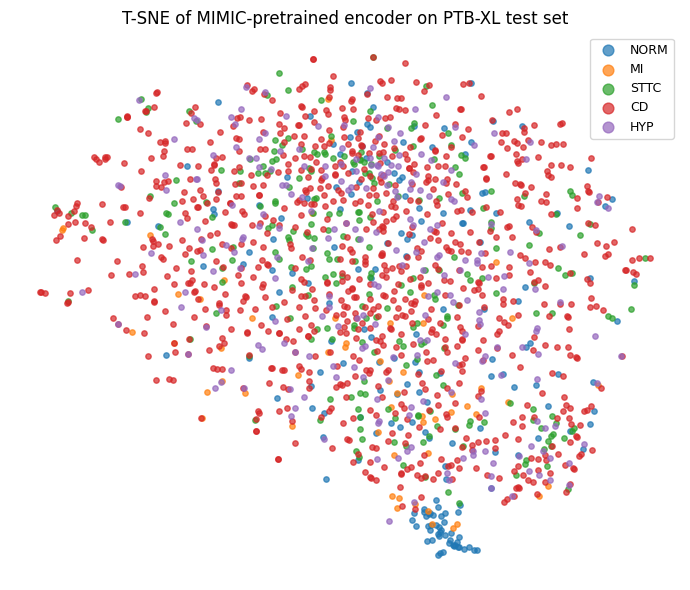

In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

single_mask = (test_labels.sum(dim=1) == 1)
embs = test_features[single_mask].numpy()
classes_array = test_labels[single_mask].argmax(dim=1).numpy()
print(f"Single-label test samples: {len(embs)} / {len(test_labels)}")

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
proj = tsne.fit_transform(embs)

CLASS_NAMES = ["NORM", "MI", "STTC", "CD", "HYP"]
colors = plt.cm.tab10(np.arange(len(CLASS_NAMES)))

fig, ax = plt.subplots(figsize=(7, 6))
for cls_idx, name in enumerate(CLASS_NAMES):
    mask = classes_array == cls_idx
    ax.scatter(proj[mask, 0], proj[mask, 1], c=[colors[cls_idx]], label=name, s=15, alpha=0.7)
ax.set_title("T-SNE of MIMIC-pretrained encoder on PTB-XL test set")
ax.legend(loc="best", markerscale=2, fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()